In [1]:
import numpy as np
import xarray as xr
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')
import cartopy.crs as ccrs
import cartopy.feature as cfeature
cmap = plt.cm.get_cmap('RdYlBu_r')

/var/folders/7w/k64x4hxx1x96s_hxn35hcg0w0000gp/T/ipykernel_21764/1623294169.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlBu_r')


In [2]:
x = np.load('/Volumes/rvmartin2/Active/yany1/1.project/NO2_DL_global_2019/NO2_global_pkg/input_variables/tSATLON_global_MAP.npy')
y = np.load('/Volumes/rvmartin2/Active/yany1/1.project/NO2_DL_global_2019/NO2_global_pkg/input_variables/tSATLAT_global_MAP.npy')

In [3]:
ISA_input_indir = '/Volumes/rvmartin2/Active/yany1/1.project/NO2_DL_global_2019/NO2_global_pkg/input_variables/ISA_input/'
ISA_file = ISA_input_indir + '2010/ISA_NOAA_001x001_global_2010.npy'
ISA_mapdata = np.load(ISA_file)

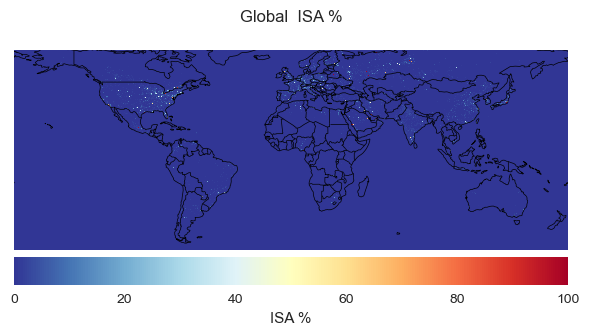

In [6]:
fig, ax = plt.subplots(figsize=(6, 4), 
                        subplot_kw={'projection': ccrs.PlateCarree()})

ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_extent([-180, 180, -60, 70], crs=ccrs.PlateCarree())

mesh = ax.pcolormesh(x, y, ISA_mapdata, 
                    transform=ccrs.PlateCarree(),
                    cmap=cmap,
                    vmin=np.nanmin(ISA_mapdata),
                    vmax=np.nanmax(ISA_mapdata))

cbar = plt.colorbar(mesh, ax=ax, orientation='horizontal', pad=0.02)
cbar.set_label('ISA %')

plt.title('Global  ISA %', pad=20)

plt.tight_layout()
plt.show()

In [5]:
fig.savefig(f'{ISA_input_indir}2010/Global_ISA_2010_nb.png', dpi=300)